# 🌊 Notebook 03: Quantum Annealing con D-Wave

**Herramienta:** D-Wave Ocean SDK + SimulatedAnnealingSampler  
**Objetivo:** Resolver el Knapsack Problem usando Quantum Annealing (simulado localmente)  
**Ejecución:** 100% local — no se requiere cuenta D-Wave  
**Tiempo estimado:** 15 minutos

---

## 1. Repaso Teórico: Quantum Annealing

### El Teorema Adiabático
Si un sistema cuántico evoluciona **suficientemente lento** desde un Hamiltoniano inicial $H_{\text{init}}$
hacia un Hamiltoniano final $H_{\text{final}}$, el sistema permanecerá en su **estado base**.

$$H(t) = \left(1 - \frac{t}{T}\right) H_{\text{init}} + \frac{t}{T} \, H_{\text{final}}$$

- $H_{\text{init}}$: Hamiltoniano fácil (superposición uniforme)
- $H_{\text{final}} = H_C$: Hamiltoniano del problema (QUBO/Ising)
- El estado base de $H_C$ codifica la **solución óptima**

### Formulación QUBO manual

En este notebook construiremos el QUBO **manualmente** para entender cada término:

$$\min \;\; C(\mathbf{x}, \mathbf{s}) = \underbrace{-\sum_{i=1}^{5} v_i x_i}_{\text{objetivo}} + \lambda \underbrace{\left( \sum_{i=1}^{5} w_i x_i + \sum_{k=0}^{3} 2^k s_k - 15 \right)^2}_{\text{penalización de restricción}}$$

## 2. Importar Librerías

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# D-Wave Ocean SDK
import dimod
from dwave.samplers import SimulatedAnnealingSampler

print(f"dimod versión: {dimod.__version__}")
print(f"Sampler: SimulatedAnnealingSampler (ejecución local)")

dimod versión: 0.12.22
Sampler: SimulatedAnnealingSampler (ejecución local)


## 3. Cargar la Instancia del Problema

In [6]:
with open('../data/knapsack_instance.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

items = data['items']
W = data['capacidad']
n = len(items)

valores = [item['valor'] for item in items]
pesos   = [item['peso']  for item in items]
nombres = [item['nombre'] for item in items]

print(f"Instancia: {n} ítems, capacidad W = {W}")
for item in items:
    print(f"  {item['nombre']:10s}  valor={item['valor']:2d}  peso={item['peso']}")

Instancia: 5 ítems, capacidad W = 15
  Laptop      valor= 5  peso=3
  Cámara      valor=10  peso=5
  Proyector   valor=15  peso=7
  Tablet      valor= 4  peso=2
  Dron        valor=12  peso=6


## 4. Construcción Manual del QUBO

### 4.1 Variables

| Variable | Significado | Coeficiente en restricción |
|----------|-------------|---------------------------|
| $x_0$ | Laptop | $w_0 = 3$ |
| $x_1$ | Cámara | $w_1 = 5$ |
| $x_2$ | Proyector | $w_2 = 7$ |
| $x_3$ | Tablet | $w_3 = 2$ |
| $x_4$ | Dron | $w_4 = 6$ |
| $s_0$ | Slack bit 0 | $2^0 = 1$ |
| $s_1$ | Slack bit 1 | $2^1 = 2$ |
| $s_2$ | Slack bit 2 | $2^2 = 4$ |
| $s_3$ | Slack bit 3 | $2^3 = 8$ |

### 4.2 Expansión binaria del slack

$$s = s_0 + 2s_1 + 4s_2 + 8s_3$$

Esto permite representar $s \in \{0, 1, 2, \ldots, 15\}$ con 4 bits:

| $s_3$ | $s_2$ | $s_1$ | $s_0$ | $s$ |
|-------|-------|-------|-------|-----|
| 0 | 0 | 0 | 0 | 0 |
| 0 | 0 | 0 | 1 | 1 |
| ... | ... | ... | ... | ... |
| 1 | 1 | 1 | 1 | 15 |

In [7]:
# --- Parámetros ---
num_slack = 4  # Bits para representar slack 0..15
lam = max(valores) + 1  # Penalización λ = 16 (debe ser > max valor individual)

print(f"Penalización λ = {lam}")
print(f"Bits de slack: {num_slack} (rango 0-{2**num_slack - 1})")
print(f"Total de variables binarias: {n + num_slack}")

# --- Nombres de variables ---
var_items = [f'x_{i}' for i in range(n)]          # x_0..x_4
var_slack = [f's_{k}' for k in range(num_slack)]   # s_0..s_3
all_vars = var_items + var_slack

# --- Coeficientes en la restricción ---
# Restricción: sum(w_i * x_i) + sum(2^k * s_k) = W
coefs = {}
for i in range(n):
    coefs[var_items[i]] = pesos[i]
for k in range(num_slack):
    coefs[var_slack[k]] = 2**k

print(f"\nCoeficientes en la restricción de igualdad:")
for var, c in coefs.items():
    print(f"  {var}: {c}")
print(f"  Constante: -{W}")

Penalización λ = 16
Bits de slack: 4 (rango 0-15)
Total de variables binarias: 9

Coeficientes en la restricción de igualdad:
  x_0: 3
  x_1: 5
  x_2: 7
  x_3: 2
  x_4: 6
  s_0: 1
  s_1: 2
  s_2: 4
  s_3: 8
  Constante: -15


In [8]:
# --- Construir el BQM (Binary Quadratic Model) ---
bqm = dimod.BinaryQuadraticModel(vartype='BINARY')

# ===== TÉRMINO 1: Función objetivo =====
# -sum(v_i * x_i)  (minimizamos el negativo del valor)
for i in range(n):
    bqm.add_variable(var_items[i], -valores[i])

print("Término objetivo: " + " ".join(f"{-v}·{x}" for v, x in zip(valores, var_items)))

# ===== TÉRMINO 2: Penalización de la restricción =====
# λ * (sum(c_j * y_j) - W)²
# donde y_j son todas las variables (ítems + slack)
# y c_j son sus coeficientes
#
# Expandiendo (A - W)² = A² - 2WA + W²
# A = sum(c_j * y_j)
# A² = sum_j(c_j² * y_j²) + 2*sum_{j<k}(c_j * c_k * y_j * y_k)
# Para binarias: y_j² = y_j

vars_list = list(coefs.keys())
c_list = list(coefs.values())

for j in range(len(vars_list)):
    # Término diagonal: λ * c_j² * y_j - 2λW * c_j * y_j
    # = λ * c_j * (c_j - 2W) * y_j  (usando y_j² = y_j)
    bqm.add_variable(vars_list[j], lam * c_list[j] * (c_list[j] - 2 * W))
    
    for k in range(j + 1, len(vars_list)):
        # Término cuadrático: 2λ * c_j * c_k * y_j * y_k
        bqm.add_interaction(vars_list[j], vars_list[k], 2 * lam * c_list[j] * c_list[k])

# Término constante: λ * W²
bqm.offset += lam * W**2

print(f"\nBQM construido:")
print(f"  Variables: {bqm.num_variables}")
print(f"  Interacciones: {bqm.num_interactions}")
print(f"  Offset: {bqm.offset}")

Término objetivo: -5·x_0 -10·x_1 -15·x_2 -4·x_3 -12·x_4

BQM construido:
  Variables: 9
  Interacciones: 36
  Offset: 3600.0


## 5. Ejecutar Simulated Annealing

Usamos `SimulatedAnnealingSampler` de D-Wave, que emula el proceso de Quantum Annealing
de forma clásica. Es ideal para pruebas locales sin hardware cuántico.

In [10]:
# Crear sampler de Simulated Annealing
sampler = SimulatedAnnealingSampler()

# Ejecutar sampling con múltiples lecturas
num_reads = 1000
print(f"Ejecutando Simulated Annealing con {num_reads} lecturas...")

sampleset = sampler.sample(bqm, num_reads=num_reads, seed=42)

print(f"Completado. Soluciones únicas encontradas: {len(sampleset)}")
print(f"\nMejores 5 soluciones (por energía):")
print(f"{'─'*80}")

for i, (sample, energy, num_occ) in enumerate(sampleset.data(['sample', 'energy', 'num_occurrences'])):
    if i >= 5:
        break
    items_sel = [nombres[j] for j in range(n) if sample[f'x_{j}'] == 1]
    peso = sum(pesos[j] for j in range(n) if sample[f'x_{j}'] == 1)
    valor = sum(valores[j] for j in range(n) if sample[f'x_{j}'] == 1)
    factible = '✅' if peso <= W else '❌'
    print(f"  #{i+1}: energía={energy:8.1f}  valor={valor:2d}  peso={peso:2d}/{W}  {factible}  ocurrencias={num_occ}  ítems={items_sel}")

Ejecutando Simulated Annealing con 1000 lecturas...
Completado. Soluciones únicas encontradas: 1000

Mejores 5 soluciones (por energía):
────────────────────────────────────────────────────────────────────────────────
  #1: energía=   -31.0  valor=31  peso=15/15  ✅  ocurrencias=1  ítems=['Proyector', 'Tablet', 'Dron']
  #2: energía=   -31.0  valor=31  peso=15/15  ✅  ocurrencias=1  ítems=['Proyector', 'Tablet', 'Dron']
  #3: energía=   -31.0  valor=31  peso=15/15  ✅  ocurrencias=1  ítems=['Proyector', 'Tablet', 'Dron']
  #4: energía=   -31.0  valor=31  peso=15/15  ✅  ocurrencias=1  ítems=['Proyector', 'Tablet', 'Dron']
  #5: energía=   -31.0  valor=31  peso=15/15  ✅  ocurrencias=1  ítems=['Proyector', 'Tablet', 'Dron']


## 6. Filtrar Soluciones Factibles

In [11]:
# Filtrar solo soluciones que respetan la restricción de capacidad
best_value = -1
best_sample = None
factibles = 0
total_muestras = 0

for sample, energy, num_occ in sampleset.data(['sample', 'energy', 'num_occurrences']):
    total_muestras += num_occ
    peso = sum(pesos[j] * sample[f'x_{j}'] for j in range(n))
    valor = sum(valores[j] * sample[f'x_{j}'] for j in range(n))
    
    if peso <= W:
        factibles += num_occ
        if valor > best_value:
            best_value = valor
            best_sample = sample

print(f"Soluciones factibles: {factibles}/{total_muestras} ({100*factibles/total_muestras:.1f}%)")

# Mostrar mejor solución
print(f"\n🎯 MEJOR SOLUCIÓN D-WAVE:")
print(f"{'─'*50}")

peso_dwave = 0
valor_dwave = 0
for i in range(n):
    sel = int(best_sample[f'x_{i}'])
    marca = '✅' if sel else '  '
    print(f"  {marca} x_{i} = {sel}  │  {nombres[i]:10s}  │  valor={valores[i]:2d}  │  peso={pesos[i]}")
    if sel:
        peso_dwave += pesos[i]
        valor_dwave += valores[i]

# Slack
slack_val = sum(2**k * int(best_sample[f's_{k}']) for k in range(num_slack))
print(f"{'─'*50}")
print(f"  Valor total:  {valor_dwave}")
print(f"  Peso total:   {peso_dwave} / {W}")
print(f"  Slack:        {slack_val} (holgura = W - peso)")
print(f"  ¿Óptimo?:    {'✅ Sí' if valor_dwave == 31 else '⚠️ Subóptimo'}")

Soluciones factibles: 987/1000 (98.7%)

🎯 MEJOR SOLUCIÓN D-WAVE:
──────────────────────────────────────────────────
     x_0 = 0  │  Laptop      │  valor= 5  │  peso=3
     x_1 = 0  │  Cámara      │  valor=10  │  peso=5
  ✅ x_2 = 1  │  Proyector   │  valor=15  │  peso=7
  ✅ x_3 = 1  │  Tablet      │  valor= 4  │  peso=2
  ✅ x_4 = 1  │  Dron        │  valor=12  │  peso=6
──────────────────────────────────────────────────
  Valor total:  31
  Peso total:   15 / 15
  Slack:        0 (holgura = W - peso)
  ¿Óptimo?:    ✅ Sí


## 7. Visualización y Comparativa Final

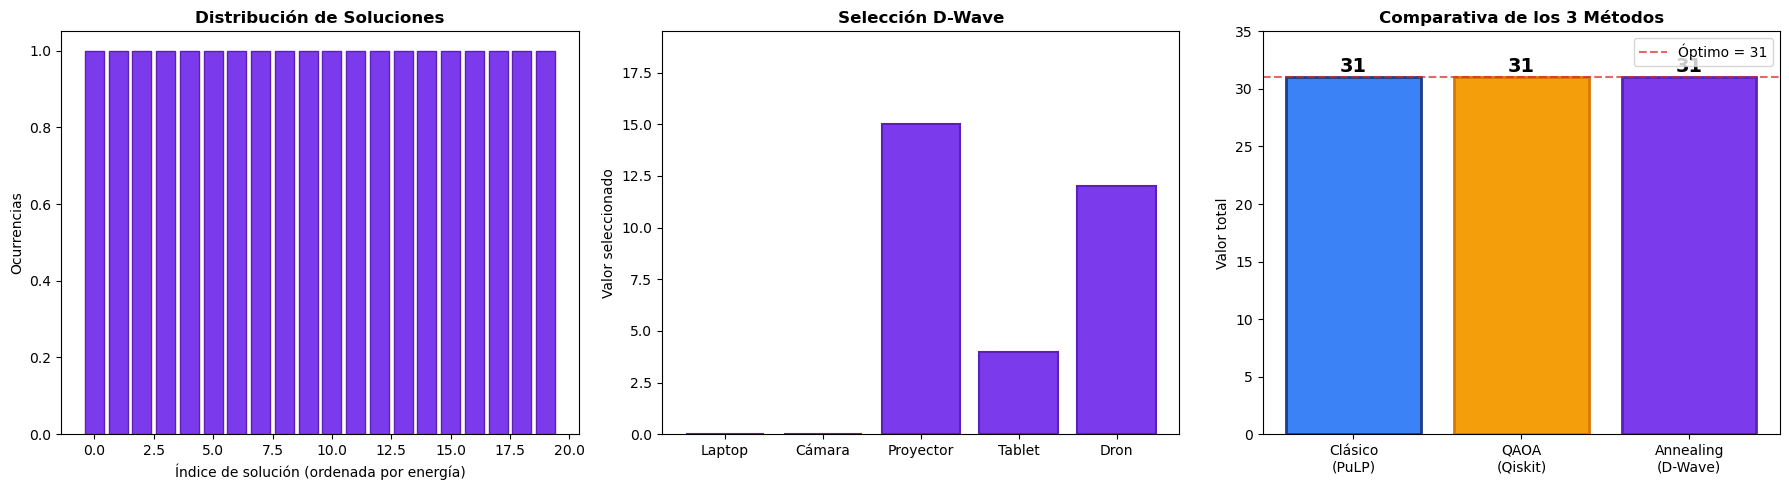

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1: Histograma de energías ---
energias = [e for _, e, _ in sampleset.data(['sample', 'energy', 'num_occurrences'])]
ocurrencias = [o for _, _, o in sampleset.data(['sample', 'energy', 'num_occurrences'])]
axes[0].bar(range(min(20, len(energias))), ocurrencias[:20], color='#7C3AED', edgecolor='#5B21B6')
axes[0].set_xlabel('Índice de solución (ordenada por energía)')
axes[0].set_ylabel('Ocurrencias')
axes[0].set_title('Distribución de Soluciones', fontweight='bold')

# --- 2: Selección D-Wave ---
dwave_sel = [int(best_sample[f'x_{i}']) for i in range(n)]
colores = ['#7C3AED' if s else '#E2E8F0' for s in dwave_sel]
bars = axes[1].bar(nombres, [v*s for v, s in zip(valores, dwave_sel)], color=colores, edgecolor='#5B21B6', linewidth=1.5)
axes[1].set_ylabel('Valor seleccionado')
axes[1].set_title('Selección D-Wave', fontweight='bold')
axes[1].set_ylim(0, max(valores) * 1.3)

# --- 3: Comparativa de los 3 métodos ---
metodos = ['Clásico\n(PuLP)', 'QAOA\n(Qiskit)', 'Annealing\n(D-Wave)']
val_comparativa = [31, 31, valor_dwave]  # Ajustar según resultados reales
colores_met = ['#3B82F6', '#F59E0B', '#7C3AED']

bars3 = axes[2].bar(metodos, val_comparativa, color=colores_met,
                     edgecolor=['#1E3A8A', '#D97706', '#5B21B6'], linewidth=2)
axes[2].set_ylabel('Valor total')
axes[2].set_title('Comparativa de los 3 Métodos', fontweight='bold')
axes[2].set_ylim(0, 35)
axes[2].axhline(y=31, color='#DC2626', linestyle='--', alpha=0.7, label='Óptimo = 31')
axes[2].legend()

for bar, val in zip(bars3, val_comparativa):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 8. Tabla Comparativa Final

| Aspecto | Clásico (PuLP) | QAOA (Qiskit) | Quantum Annealing (D-Wave) |
|---------|---------------|---------------|---------------------------|
| **Tipo** | Exacto (ILP) | Variacional | Metaheurístico |
| **Garantía** | Solución óptima | Aproximada | Aproximada |
| **Formulación** | ILP directo | QUBO → Ising | QUBO → BQM |
| **Escalabilidad** | ~miles de vars | ~cientos de qubits | ~miles de qubits (QPU) |
| **Hardware** | CPU clásica | Procesador cuántico de compuertas | Procesador cuántico de annealing |
| **Simulación local** | ✅ Siempre | ✅ StatevectorSampler | ✅ SimulatedAnnealingSampler |

### Conclusión
Para problemas pequeños, el solver clásico es imbatible. La ventaja cuántica potencial
aparece en problemas de gran escala donde los solvers clásicos se vuelven impracticables.